In [2]:
# Fruit single shot detector

## 0. Imports and global functions.

In [97]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
import tensorflow as tf
import xml.etree.ElementTree as ET
from google.colab import auth
from googleapiclient.discovery import build
from google.colab import userdata

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Conv2D, BatchNormalization, LeakyReLU, Dropout, Reshape, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import Callback, EarlyStopping
import tensorflow.keras.backend as K
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from sklearn.model_selection import train_test_split
import tensorflow as tf

from googleapiclient.http import MediaFileUpload, MediaIoBaseDownload
import io
import os

# Request permissions to access (read/write) the Google Drive Folder ID
GOOGLE_DRIVE_FOLDER_ID = "14LvaZfifLwoGsnIbwINaEZMSLEpP4E4-"
auth.authenticate_user()
drive_service = build('drive', 'v3')

# 1. Función para guardar en Google Drive
def save_model_to_drive(model_obj, filename):
    # Primero guardamos localmente
    local_path = f"/content/{filename}"
    model_obj.save(local_path)
    print(f"Modelo guardado localmente en {local_path}")

    # Metadatos para Drive
    file_metadata = {
        'name': filename,
        'parents': [GOOGLE_DRIVE_FOLDER_ID]
    }

    media = MediaFileUpload(local_path, mimetype='application/octet-stream')

    # Subir
    print("Subiendo a Google Drive...")
    file = drive_service.files().create(
        body=file_metadata,
        media_body=media,
        fields='id'
    ).execute()

    print(f"Modelo subido con ID: {file.get('id')}")


def load_model_from_drive(filename, folder_id, drive_service, custom_objects=None):
    """
    Descarga un modelo de una carpeta específica de Google Drive y lo carga en Keras.

    Args:
        filename (str): El nombre exacto del archivo .keras en Drive.
        folder_id (str): El ID de la carpeta en Google Drive donde está el archivo.
        drive_service: La instancia autenticada del servicio de Drive.
        custom_objects (dict): Diccionario para mapear funciones personalizadas (ej. robust_loss).

    Returns:
        model: El modelo de Keras cargado.
    """
    print(f"Buscando '{filename}' en la carpeta de Drive...")

    # 1. Buscar el ID del archivo por su nombre dentro de la carpeta
    query = f"name = '{filename}' and '{folder_id}' in parents and trashed = false"
    results = drive_service.files().list(q=query, fields="files(id, name)").execute()
    items = results.get('files', [])

    if not items:
        raise FileNotFoundError(f"No se encontró el archivo '{filename}' en la carpeta con ID {folder_id}.")

    # Tomamos el primer archivo que coincida (por si hay duplicados)
    file_id = items[0]['id']
    print(f"Archivo encontrado. ID: {file_id}. Descargando...")

    # 2. Descargar el archivo a un buffer o archivo temporal
    request = drive_service.files().get_media(fileId=file_id)

    # Ruta local temporal para guardar el modelo descargado
    local_path = f"/content/downloaded_{filename}"

    with io.FileIO(local_path, 'wb') as fh:
        downloader = MediaIoBaseDownload(fh, request)
        done = False
        while done is False:
            status, done = downloader.next_chunk()
            print(f"Descarga {int(status.progress() * 100)}%.")

    print("Descarga completa. Cargando modelo en memoria...")

    # 3. Cargar el modelo con Keras
    # IMPORTANTE: Pasamos custom_objects para que reconozca la loss function
    try:
        model = load_model(local_path, custom_objects=custom_objects)
        print("Modelo cargado exitosamente.")
        return model
    except Exception as e:
        print(f"Error al cargar el modelo con Keras: {e}")
        return None

import numpy as np
import tensorflow as tf

def decode_prediction(grid, threshold=0.5, iou_threshold=0.4):
    """
    Decodes the 7x7x8 prediction grid back into bounding boxes.
    Applies Non-Maximum Suppression (NMS) to remove overlapping duplicates.

    Args:
        grid: numpy array of shape (7, 7, 8) representing the model output/target.
        threshold: Minimum confidence score to consider an object.
        iou_threshold: Intersection over Union threshold for NMS.

    Returns:
        A list of lists: [[xmin, ymin, xmax, ymax, class_idx, confidence], ...]
    """
    boxes = []
    scores = []
    classes = []

    grid_size = grid.shape[0]

    # 1. Extract raw predictions filtering by confidence
    for row in range(grid_size):
        for col in range(grid_size):
            conf = grid[row, col, 0]

            if conf >= threshold:
                # Extract coordinates (normalized 0-1)
                cx, cy, w, h = grid[row, col, 1:5]

                # Extract class probabilities and get the highest one
                class_probs = grid[row, col, 5:]
                class_idx = np.argmax(class_probs)

                # Convert Center/Width/Height to Min/Max format
                xmin = cx - (w / 2.0)
                ymin = cy - (h / 2.0)
                xmax = cx + (w / 2.0)
                ymax = cy + (h / 2.0)

                # Clip coordinates to remain strictly within the image [0.0, 1.0]
                xmin, ymin = max(0.0, min(xmin, 1.0)), max(0.0, min(ymin, 1.0))
                xmax, ymax = max(0.0, min(xmax, 1.0)), max(0.0, min(ymax, 1.0))

                # tf.image.non_max_suppression expects [ymin, xmin, ymax, xmax]
                boxes.append([ymin, xmin, ymax, xmax])
                scores.append(conf)
                classes.append(class_idx)

    if not boxes:
        return []

    boxes = np.array(boxes)
    scores = np.array(scores)

    # 2. Apply Non-Maximum Suppression (NMS)
    # This removes multiple boxes pointing to the same object
    selected_indices = tf.image.non_max_suppression(
        boxes,
        scores,
        max_output_size=15, # Max objects to detect per image
        iou_threshold=iou_threshold
    )

    # 3. Format output mapping back to standard [xmin, ymin, xmax, ymax]
    results = []
    for idx in selected_indices:
        ymin, xmin, ymax, xmax = boxes[idx]
        results.append([xmin, ymin, xmax, ymax, classes[idx], scores[idx]])

    return results

class SingleFileDriveCheckpoint(Callback):
    """
    Overwrites the same file in Google Drive only if val_loss improves.
    Keeps Drive clean.
    """
    def __init__(self, drive_service, folder_id, filename='best_fruit_model.keras', monitor='val_loss', verbose=1):
        super(SingleFileDriveCheckpoint, self).__init__()
        self.drive_service = drive_service
        self.folder_id = folder_id
        self.filename = filename
        self.monitor = monitor
        self.verbose = verbose
        self.best = float('inf')
        self.file_id = None # To track the existing file ID in Drive

    def on_epoch_end(self, epoch, logs=None):
        current = logs.get(self.monitor)
        if current is None: return

        if current < self.best:
            if self.verbose > 0:
                print(f"\nEpoch {epoch+1}: {self.monitor} improved from {self.best:.4f} to {current:.4f}. Updating Drive...")

            self.best = current
            self._save_and_overwrite(current)

    def _save_and_overwrite(self, loss_value):
        local_path = f"/content/{self.filename}"
        self.model.save(local_path)

        # Define metadata
        file_metadata = {
            'name': self.filename,
            'parents': [self.folder_id]
        }
        media = MediaFileUpload(local_path, mimetype='application/octet-stream')

        try:
            # Check if file already exists to update it (PATCH) instead of creating new (POST)
            if self.file_id is None:
                # Search for it first
                query = f"name = '{self.filename}' and '{self.folder_id}' in parents and trashed = false"
                results = self.drive_service.files().list(q=query, fields="files(id)").execute()
                items = results.get('files', [])
                if items:
                    self.file_id = items[0]['id']

            if self.file_id:
                # Update existing file
                self.drive_service.files().update(
                    fileId=self.file_id,
                    media_body=media
                ).execute()
                if self.verbose > 0: print(f"Updated existing file ID: {self.file_id}")
            else:
                # Create new file
                file = self.drive_service.files().create(
                    body=file_metadata,
                    media_body=media,
                    fields='id'
                ).execute()
                self.file_id = file.get('id')
                if self.verbose > 0: print(f"Created new file ID: {self.file_id}")

        except Exception as e:
            print(f"Drive Upload Error: {e}")
        finally:
            if os.path.exists(local_path):
                os.remove(local_path)

## 1. Download dataset.

In [98]:

KAGGLE_DATASET = "mbkinaci/fruit-images-for-object-detection"
BASE_DIR = "/content/fruit_data"
MODEL_TO_LOAD = "fruit_detector_v1.keras"
MODEL_TO_SAVE = "fruit_detector_v1.keras"

# Configurar Kaggle
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# Descargar y descomprimir
if not os.path.exists(BASE_DIR):
    print("Download dataset...")
    !kaggle datasets download -d {KAGGLE_DATASET}
    !unzip -q fruit-images-for-object-detection.zip -d {BASE_DIR}
    print(f"Dataset download in {BASE_DIR}")
else:
    print("The dataset has been already downloaded.")

# Verificar estructura
print("Dataset Folders:", os.listdir(BASE_DIR))

The dataset has been already downloaded.
Dataset Folders: ['test_zip', 'train_zip']


## 3. Pre-processing
Regroup the dataset annotations so that each unique image is associated with all its bounding boxes and labels, eliminating the duplicate image entries found in the current variables. You should re-process the data from /content/fruit_data or restructure the existing arrays.

After grouping, implement a Target Encoder to map the variable-length ground truth boxes to a fixed-size grid tensor (e.g., 7x7). This encoder should assign objects to grid cells based on their center coordinates (similar to YOLO or simplified SSD), creating the target tensors required for training.

## 3.1 Encode features

In [99]:
# Parámetros
GRID_SIZE = 7
IMG_WIDTH = 224
IMG_HEIGHT = 224
BATCH_SIZE = 32

# Mapeo de Clases
CLASS_MAP = {"apple": 0, "banana": 1, "orange": 2}
INV_CLASS_MAP = {0: "apple", 1: "banana", 2: "orange"}

# Get image shape
def get_image_dimensions(img_path):
    try:
        img = cv2.imread(img_path)
        if img is not None:
            height, width, _ = img.shape
            return width, height
        else:
            print(f"Error: The image could not be loaded from the path: {img_path}")
            return None, None
    except Exception as e:
        print(f"Error trying to read the image: {img_path}: {e}")
        return None, None

# Load the datasets
def load_grouped_data(directory):
    images = []
    all_annotations = []

    # Iterate through all files in the directory
    for root_dir, dirs, files in os.walk(directory):
        for file in files:
            if file.endswith(".xml"):
                xml_path = os.path.join(root_dir, file)

                # Parse XML
                tree = ET.parse(xml_path)
                root = tree.getroot()

                # Get image path
                filename = root.find("filename").text
                img_path = os.path.join(root_dir, filename)

                if not os.path.exists(img_path):
                  print(f"Image not found: {img_path}")
                  continue

                # Get original dimensions
                size = root.find("size")
                # many of the xml files were setting with width=0, height=0
                # w_orig = int(size.find("width").text)
                # h_orig = int(size.find("height").text)
                w_orig, h_orig = get_image_dimensions(os.path.join(directory, filename))


                # Find all valid objects
                objects = root.findall("object")
                img_boxes = []

                for obj in objects:
                    name = obj.find("name").text
                    if name in CLASS_MAP:
                        label = CLASS_MAP[name]
                        bndbox = obj.find("bndbox")
                        xmin = int(bndbox.find("xmin").text)
                        ymin = int(bndbox.find("ymin").text)
                        xmax = int(bndbox.find("xmax").text)
                        ymax = int(bndbox.find("ymax").text)


                        # Store as [xmin_norm, ymin_norm, xmax_norm, ymax_norm, label] for now
                        # Actually, keeping min/max for flexibility or converting to center/size directly?
                        # The instructions say "Normalize the bounding box coordinates to [0, 1]"
                        # Let's store [xmin/w, ymin/h, xmax/w, ymax/h, label]
                        img_boxes.append([
                            xmin / w_orig, ymin / h_orig, xmax / w_orig, ymax / h_orig, label
                        ])

                if img_boxes:
                    # Load and resize image
                    try:
                        img = load_img(img_path, target_size=(IMG_WIDTH, IMG_HEIGHT))
                        img_arr = img_to_array(img) / 255.0
                        images.append(img_arr)
                        all_annotations.append(img_boxes)
                    except Exception as e:
                        print(f"Error loading {img_path}: {e}")

    return np.array(images, dtype="float32"), all_annotations


# 1. Cargar los datos (Tu código original)
print("Reloading Train Data...")
X_train, train_bboxes = load_grouped_data(os.path.join(BASE_DIR, "train_zip", "train"))

print("Reloading original Test Data (to be split)...")
X_test_full, test_bboxes_full = load_grouped_data(os.path.join(BASE_DIR, "test_zip", "test"))

# 2. Dividir el Test Set en Validation y Test
# Usamos un test_size=0.5 para dividirlo exactamente a la mitad
print("Splitting data into Validation and Test sets...")

X_val, X_test, val_bboxes, test_bboxes = train_test_split(
    X_test_full,
    test_bboxes_full,
    test_size=0.5,
    random_state=42, # Semilla fija para que siempre divida igual
    shuffle=True
)

print(f"Final Shapes:")
print(f" - Train: {X_train.shape}")
print(f" - Validation: {X_val.shape}")
print(f" - Test: {X_test.shape}")


Reloading Train Data...


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Reloading original Test Data (to be split)...
Splitting data into Validation and Test sets...
Final Shapes:
 - Train: (240, 224, 224, 3)
 - Validation: (30, 224, 224, 3)
 - Test: (30, 224, 224, 3)


## 3.2 Encode labels


- Frame the image in a 7 x 7 grid
- Get the SSD/YOLO cordenates confidence, centerX, centerY, width , height, one hot encode of the class [apple, banana, orange]


**Tensor Population:**

    *   At the calculated `[row, col]` index, it fills the depth vector `[8]` with:

        *   **Index 0:** Confidence = `1.0` (Object Present).
        *   **Index 1-4:** Coordinates `[cx, cy, w, h]`.
        *   **Index 5-7:** One-hot encoded Class Label (e.g., `[1, 0, 0]` for Apple).


**Output Vector Structure:**

`[ Confidence, cx, cy, w, h, Class0, Class1, Class2 ]`


In [100]:
# Target Encoder for SSD/YOLO style grid
def encode_target(bboxes_list, grid_size=GRID_SIZE, num_classes=3):
    # Output: (7, 7, 8) -> [confidence, cx, cy, w, h, c0, c1, c2]
    target = np.zeros((grid_size, grid_size, 5 + num_classes))

    for box in bboxes_list:
        xmin, ymin, xmax, ymax, label = box

        # Calculate Center and Size (normalized global)
        cx = (xmin + xmax) / 2.0
        cy = (ymin + ymax) / 2.0
        w = xmax - xmin
        h = ymax - ymin

        # Determine grid cell
        col = int(cx * grid_size)
        row = int(cy * grid_size)

        # Boundary check
        col = min(col, grid_size - 1)
        row = min(row, grid_size - 1)

        # Populate tensor if empty (or overwrite)
        # We set confidence to 1
        if target[row, col, 0] == 0:
            target[row, col, 0] = 1.0
            target[row, col, 1:5] = [cx, cy, w, h]
            target[row, col, 5 + int(label)] = 1.0

    return target

y_train = np.array([encode_target(bboxes) for bboxes in train_bboxes])

# Crear y_val (NUEVO)
y_val = np.array([encode_target(bboxes) for bboxes in val_bboxes])

# Crear y_test (Actualizado con el conjunto reducido)
y_test = np.array([encode_target(bboxes) for bboxes in test_bboxes])

print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"y_test shape: {y_test.shape}")


y_train shape: (240, 7, 7, 8)
y_val shape: (30, 7, 7, 8)
y_test shape: (30, 7, 7, 8)


## 3.3 Visualize pre-processed datasets

Visualizing index: 52 from Train dataset...


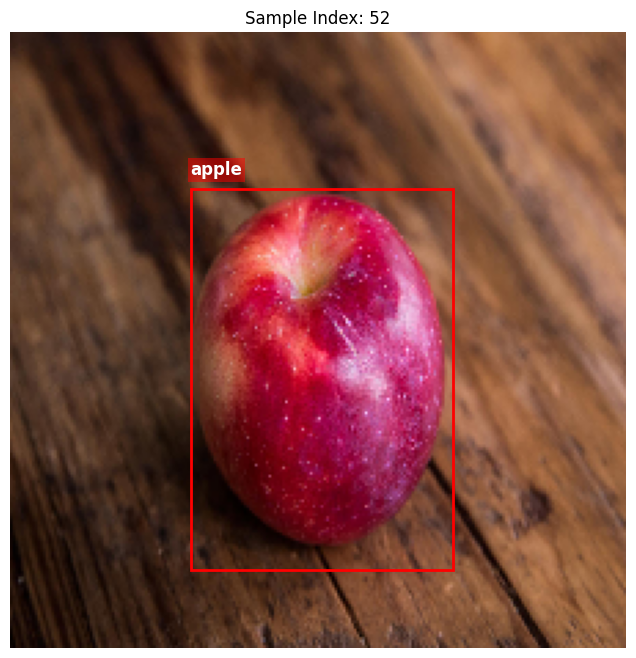

In [101]:
def visualize_dataset_sample(images, annotations, index):
    """
    Visualizes an image from the dataset with its corresponding bounding boxes and class labels.

    Args:
        images (numpy.array): The array of images (normalized 0-1).
        annotations (list): List of lists containing bounding boxes and labels.
                            Format: [[xmin, ymin, xmax, ymax, label], ...]
        index (int): The index of the image to visualize.
    """
    # 1. Retrieve image and annotations
    try:
        img = images[index]
        boxes = annotations[index]
    except IndexError:
        print(f"Error: Index {index} is out of bounds.")
        return

    # 2. Create plot
    fig, ax = plt.subplots(1, figsize=(8, 8))

    # Display the image
    # The input images are already normalized to [0, 1] based on your load_grouped_data function
    ax.imshow(img)

    # 3. Draw bounding boxes
    img_h, img_w, _ = img.shape

    if len(boxes) == 0:
        print("No objects labeled in this image.")

    for box in boxes:
        # Extract normalized coordinates and label
        # Your format: [xmin_norm, ymin_norm, xmax_norm, ymax_norm, label]
        xmin_n, ymin_n, xmax_n, ymax_n, label_idx = box

        # Denormalize coordinates to pixel values
        xmin = xmin_n * img_w
        ymin = ymin_n * img_h
        xmax = xmax_n * img_w
        ymax = ymax_n * img_h

        # Calculate width and height for the Rectangle patch
        width = xmax - xmin
        height = ymax - ymin

        # Get class name
        class_name = INV_CLASS_MAP.get(int(label_idx), "Unknown")

        # Create a Rectangle patch
        # (xy) is the bottom-left point usually, but in image coords (0,0 is top-left),
        # xy is the top-left corner of the rect.
        rect = patches.Rectangle(
            (xmin, ymin),
            width,
            height,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )

        # Add the patch to the Axes
        ax.add_patch(rect)

        # 4. Add Label Text
        # We place a background box behind text for better readability
        plt.text(
            xmin,
            ymin - 5, # Slightly above the box
            class_name,
            color='white',
            fontsize=12,
            weight='bold',
            bbox=dict(facecolor='red', alpha=0.5, edgecolor='none', pad=2)
        )

    # Final cleanup
    plt.axis('off') # Hide axes ticks
    plt.title(f"Sample Index: {index}")
    plt.show()


# Select dataset to visualize (Change to X_test/test_bboxes if desired)
target_images = X_train
target_bboxes = train_bboxes

# Calculate a random index between 0 and the maximum index
random_index = random.randint(0, len(target_images) - 1)

print(f"Visualizing index: {random_index} from Train dataset...")

# Call the visualization function
visualize_dataset_sample(target_images, target_bboxes, random_index)

## 4.1 Augment Data

In [8]:
import tensorflow as tf

def augment_data(image, label):
    """
    Applies random augmentations to the image and updates the label.
    """
    # 1. Photometric Augmentations
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    image = tf.clip_by_value(image, 0.0, 1.0)

    # 2. Random Horizontal Flip
    # Generate a random scalar for decision
    if tf.random.uniform(()) > 0.5:
        # Flip the image
        image = tf.image.flip_left_right(image)

        # Flip the grid horizontally (swap columns)
        # label shape is (7, 7, 8)
        label = tf.reverse(label, axis=[1])

        # Update cx coordinate: new_cx = 1.0 - cx
        # We need to decompose the last dimension to access cx (index 1)
        # Tensor structure: [conf, cx, cy, w, h, class...]

        # Split channels
        channels = tf.split(label, num_or_size_splits=8, axis=-1)

        conf = channels[0]
        cx = channels[1]

        # Calculate new cx
        # We multiply by conf to ensure background cells (conf=0) remain 0 instead of becoming 1.0
        new_cx = (1.0 - cx) * conf

        # Update the cx channel
        channels[1] = new_cx

        # Reassemble
        label = tf.concat(channels, axis=-1)

    return image, label

# Create Training Dataset
print("Creating Training Dataset with Augmentation...")
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.shuffle(buffer_size=len(X_train))
train_dataset = train_dataset.map(augment_data, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.batch(BATCH_SIZE)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

# Create Validation Dataset (No augmentation)
print("Creating Validation Dataset...")
val_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
val_dataset = val_dataset.batch(BATCH_SIZE)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)

# Verify
print("Train Dataset Spec:", train_dataset.element_spec)
print("Val Dataset Spec:", val_dataset.element_spec)

Creating Training Dataset with Augmentation...
Creating Validation Dataset...
Train Dataset Spec: (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 7, 7, 8), dtype=tf.float64, name=None))
Val Dataset Spec: (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 7, 7, 8), dtype=tf.float64, name=None))


### 4. 2 Visualize Augment Data

In [12]:
def visualize_augmented_dataset(dataset, num_samples=3):
    """
    Visualiza muestras directamente de un tf.data.Dataset procesado.
    Decodifica la grilla (7x7x8) de vuelta a cajas visualizables.
    """
    # 1. Extraer un solo batch del dataset (contiene 32 imágenes ya aumentadas)
    # take(1) obtiene el primer lote disponible
    for images_batch, targets_batch in dataset.take(1):

        # Convertir a numpy para poder graficar
        images = images_batch.numpy()
        targets = targets_batch.numpy()

        # Mostraremos 'num_samples' imágenes de este batch
        plt.figure(figsize=(15, 5 * num_samples))

        for i in range(num_samples):
            img = images[i]       # Imagen aumentada (brillo, flip, etc.)
            grid = targets[i]     # Target ajustado (flip de coordenadas si aplica)

            # 2. DECODIFICAR LA GRILLA
            # Usamos tu función decode_prediction con umbral alto
            # porque en el ground truth la confianza es siempre 1.0
            boxes = decode_prediction(grid, threshold=0.9)

            # 3. Configurar Plot
            ax = plt.subplot(num_samples, 1, i + 1)
            ax.imshow(img)

            img_h, img_w, _ = img.shape

            if not boxes:
                ax.text(10, 10, "No objects", color='red', backgroundcolor='white')

            # 4. Dibujar Cajas
            for box in boxes:
                # decode_prediction retorna: [xmin, ymin, xmax, ymax, label, score]
                xmin, ymin, xmax, ymax, label_idx, _ = box

                # Desnormalizar a píxeles
                x = xmin * img_w
                y = ymin * img_h
                w = (xmax - xmin) * img_w
                h = (ymax - ymin) * img_h

                # Dibujar rectángulo
                rect = patches.Rectangle(
                    (x, y), w, h,
                    linewidth=3, edgecolor='cyan', facecolor='none'
                )
                ax.add_patch(rect)

                # Texto
                class_name = INV_CLASS_MAP.get(int(label_idx), "Unknown")
                ax.text(
                    x, y - 5,
                    f"{class_name}",
                    color='cyan', fontsize=12, weight='bold',
                    bbox=dict(facecolor='black', alpha=0.5, edgecolor='none')
                )

            ax.set_title(f"Augmented Sample #{i+1}")
            ax.axis('off')

        plt.tight_layout()
        plt.show()

        # Rompemos el ciclo después del primer batch para no iterar todo el dataset
        break


Visualizando datos aumentados (Verificar Flips y Brillo)...


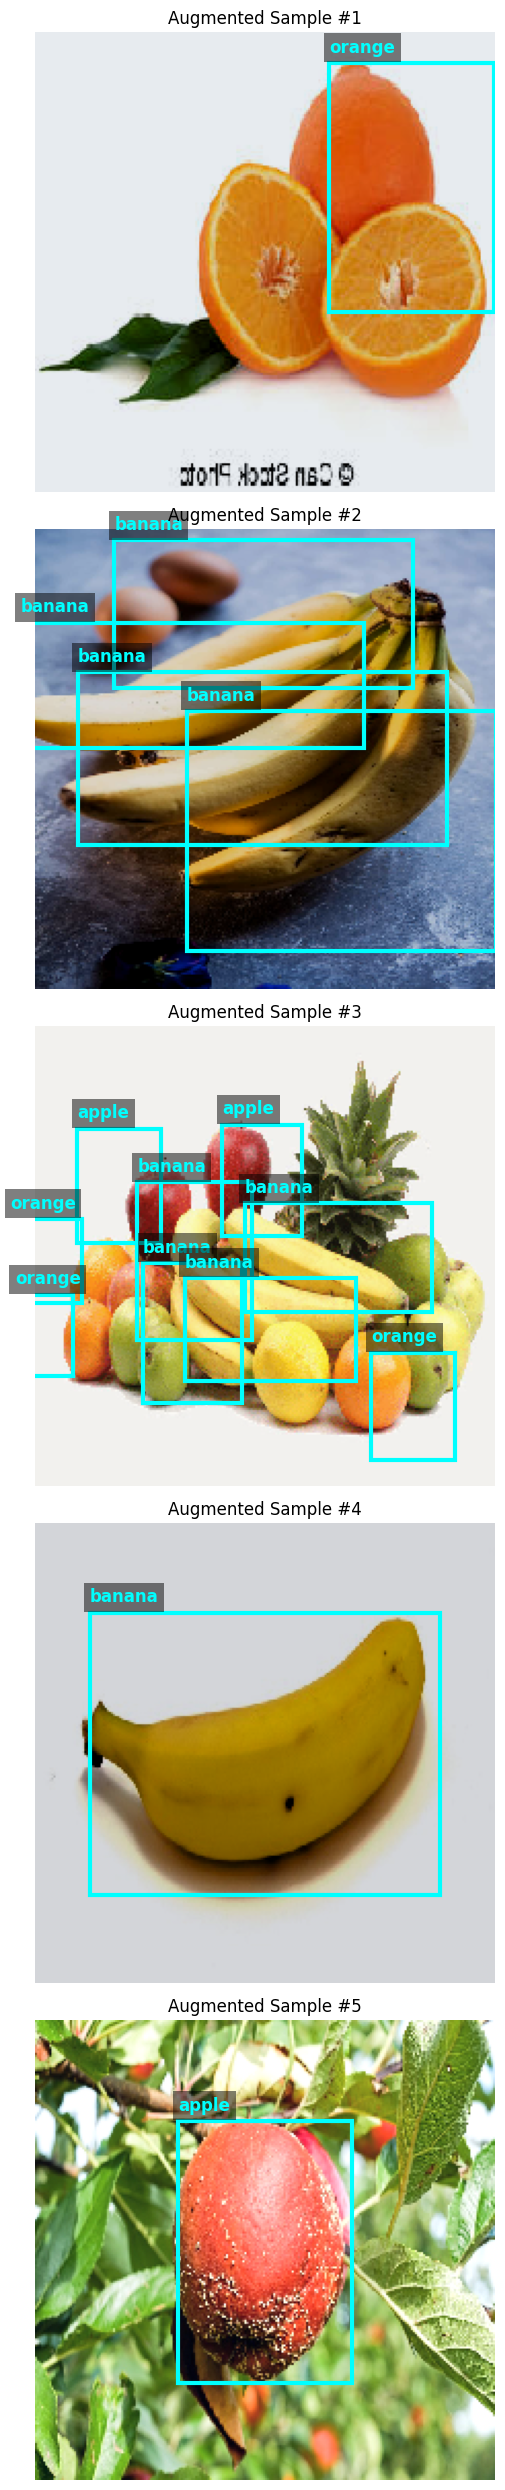

In [69]:
print("Visualizando datos aumentados (Verificar Flips y Brillo)...")
# Pásale tu dataset de entrenamiento ya creado
visualize_augmented_dataset(train_dataset, num_samples=5)

# Task
Build and compile the object detection model. First, define a `create_model` function that uses a pre-trained `ResNet50` as the backbone (input shape 224x224x3), adds a custom detection head with convolution and reshape layers, and outputs a final tensor of shape `(7, 7, 8)`. Next, implement the custom `yolo_loss` function to calculate the total loss as a weighted sum of coordinate errors (MSE), confidence errors (MSE), and class probability errors (MSE), ensuring that coordinate and class losses are only penalized when an object is present in the grid cell. Finally, instantiate the model and compile it using the Adam optimizer and the custom loss.

## Build and Compile Model

### Subtask:
Define the `create_model` function using ResNet50 as a backbone, implement the custom `yolo_loss`, and compile the model.


**Reasoning**:
Implement the model creation and custom loss function as described in the instructions. This involves defining the ResNet50-based architecture and the specific YOLO-like loss components (coordinate, object, no-object, class).



In [106]:
import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, LeakyReLU
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np

# ==========================================
# HYPERPARAMETERS DICTIONARY
# ==========================================
HYPERPARAMS = {
    "learning_rate": 1e-4,
    "batch_size": 32,
    "epochs": 50,
    "lambda_coord": 5.0,
    "lambda_iou": 3.0,      # NUEVO: Peso específico para forzar un IoU alto
    "lambda_noobj": 0.5,
    "conf_threshold": 0.5,
    "iou_threshold": 0.4
}

def build_yolo_ssd_model(input_shape=(224, 224, 3), grid_size=7, num_classes=3):
    base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
    base_model.trainable = False

    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)

    # Cuello de botella más robusto para mejorar la predicción de dimensiones
    x = Conv2D(512, (3, 3), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha=0.1)(x)

    x = Conv2D(256, (3, 3), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha=0.1)(x)

    outputs = Conv2D(5 + num_classes, (1, 1), padding='same', activation='sigmoid')(x)
    return Model(inputs, outputs, name="Fruit_Detector_MobileNet")

# -----------------------------------------------------------------
# FUNCIONES MATEMÁTICAS DE IoU Y MÉTRICAS
# -----------------------------------------------------------------
def calculate_iou_tensor(y_true, y_pred):
    """Calcula el IoU matemáticamente operando directamente sobre los tensores"""
    t_cx, t_cy, t_w, t_h = y_true[..., 1], y_true[..., 2], y_true[..., 3], y_true[..., 4]
    p_cx, p_cy, p_w, p_h = y_pred[..., 1], y_pred[..., 2], y_pred[..., 3], y_pred[..., 4]

    t_xmin, t_ymin = t_cx - t_w / 2.0, t_cy - t_h / 2.0
    t_xmax, t_ymax = t_cx + t_w / 2.0, t_cy + t_h / 2.0

    p_xmin, p_ymin = p_cx - p_w / 2.0, p_cy - p_h / 2.0
    p_xmax, p_ymax = p_cx + p_w / 2.0, p_cy + p_h / 2.0

    inter_xmin = tf.maximum(t_xmin, p_xmin)
    inter_ymin = tf.maximum(t_ymin, p_ymin)
    inter_xmax = tf.minimum(t_xmax, p_xmax)
    inter_ymax = tf.minimum(t_ymax, p_ymax)

    inter_w = tf.maximum(inter_xmax - inter_xmin, 0.0)
    inter_h = tf.maximum(inter_ymax - inter_ymin, 0.0)
    inter_area = inter_w * inter_h

    union_area = (t_w * t_h) + (p_w * p_h) - inter_area + K.epsilon()
    return inter_area / union_area

def metric_iou(y_true, y_pred):
    """Métrica para Colab: Muestra el IoU promedio en celdas con objetos"""
    obj_mask = y_true[..., 0]
    iou = calculate_iou_tensor(y_true, y_pred)
    return K.sum(iou * obj_mask) / (K.sum(obj_mask) + K.epsilon())

def metric_class_acc(y_true, y_pred):
    """Métrica para Colab: Muestra la precisión al elegir (apple, banana, orange)"""
    obj_mask = y_true[..., 0]
    true_class = K.argmax(y_true[..., 5:], axis=-1)
    pred_class = K.argmax(y_pred[..., 5:], axis=-1)
    correct = K.cast(K.equal(true_class, pred_class), K.floatx())
    return K.sum(correct * obj_mask) / (K.sum(obj_mask) + K.epsilon())

def custom_yolo_loss_v2(y_true, y_pred):
    """Función de pérdida actualizada. Incluye castigo estricto por bajo IoU."""
    obj_mask = y_true[..., 0]
    noobj_mask = 1.0 - obj_mask

    # 1. Coordinate Loss (MSE)
    coord_loss = K.sum(K.square(y_true[..., 1:5] - y_pred[..., 1:5]), axis=-1)
    coord_loss = K.sum(coord_loss * obj_mask) * HYPERPARAMS["lambda_coord"]

    # 2. IoU Loss (FORZA A LAS CAJAS A ENCAJAR PERFECTO)
    iou = calculate_iou_tensor(y_true, y_pred)
    iou_loss = K.sum((1.0 - iou) * obj_mask) * HYPERPARAMS["lambda_iou"]

    # 3. Confidence Loss
    true_conf = y_true[..., 0]
    pred_conf = K.clip(y_pred[..., 0], K.epsilon(), 1.0 - K.epsilon())
    bce = - (true_conf * K.log(pred_conf) + (1 - true_conf) * K.log(1 - pred_conf))
    conf_loss = K.sum(bce * obj_mask) + K.sum(bce * noobj_mask) * HYPERPARAMS["lambda_noobj"]

    # 4. Class Loss
    true_class = y_true[..., 5:]
    pred_class = K.clip(y_pred[..., 5:], K.epsilon(), 1.0 - K.epsilon())
    class_loss = - K.sum(true_class * K.log(pred_class), axis=-1)
    class_loss = K.sum(class_loss * obj_mask)

    total_loss = coord_loss + iou_loss + conf_loss + class_loss
    return total_loss / K.cast(K.shape(y_true)[0], K.floatx())

# Instanciar modelo
model = build_yolo_ssd_model()

## Train Model

### Subtask:
Configure callbacks and train the object detection model using the prepared datasets.


Compiling model with Custom Metrics...
Starting training (Batch: 32 | Epochs: 50)...
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - loss: 37.3976 - metric_class_acc: 0.5611 - metric_iou: 0.1992 - val_loss: 25.2447 - val_metric_class_acc: 0.9423 - val_metric_iou: 0.3026 - learning_rate: 1.0000e-04
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 30.0854 - metric_class_acc: 0.9135 - metric_iou: 0.2409 - val_loss: 14.7735 - val_metric_class_acc: 0.9423 - val_metric_iou: 0.3312 - learning_rate: 1.0000e-04
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 25.3913 - metric_class_acc: 0.9357 - metric_iou: 0.3255 - val_loss: 13.7464 - val_metric_class_acc: 0.9423 - val_metric_iou: 0.3286 - learning_rate: 1.0000e-04
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 22.0377 - metric_class_acc: 0.9543 - metric_iou: 0.3786 - val_loss: 15.4513 - val_metric_class_acc: 0.9808 - val_metric_iou: 0.2905 - learning_rate: 1.0000e-04
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step

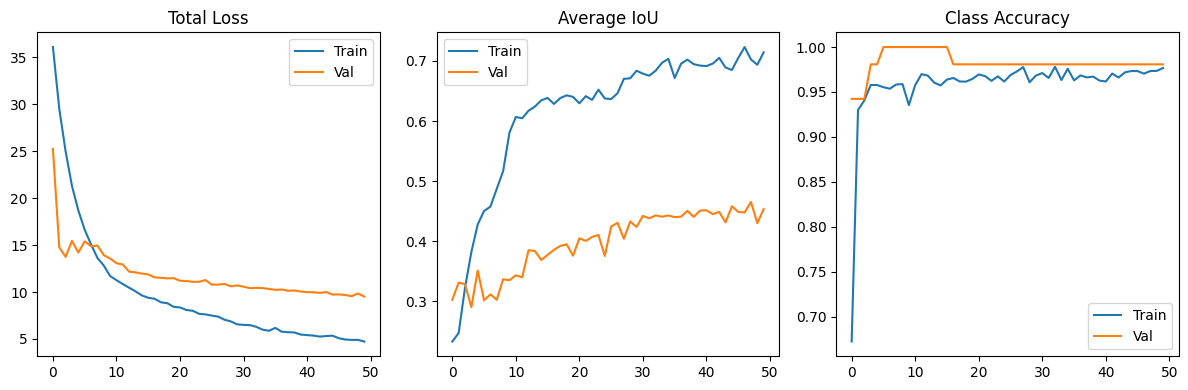

In [107]:
import matplotlib.pyplot as plt

print("Compiling model with Custom Metrics...")
# Agregamos nuestras nuevas métricas al compilador
model.compile(
    optimizer=Adam(learning_rate=HYPERPARAMS["learning_rate"]),
    loss=custom_yolo_loss_v2,
    metrics=[metric_iou, metric_class_acc]
)

early_stopping = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

print(f"Starting training (Batch: {HYPERPARAMS['batch_size']} | Epochs: {HYPERPARAMS['epochs']})...")

# Entrenar (Ahora verás metric_iou y metric_class_acc subir en cada época)
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=HYPERPARAMS["epochs"],
    batch_size=HYPERPARAMS["batch_size"],
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Evaluar de forma global en Validation Set
print("\n--- Model Final Evaluation on Validation Set ---")
val_results = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Loss: {val_results[0]:.4f}")
print(f"Validation Average IoU: {val_results[1]:.4f} (Ideal es acercarse a 1.0)")
print(f"Validation Class Accuracy: {val_results[2]*100:.2f}% (Ideal es 100%)")

# Plot
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Total Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history.history['metric_iou'], label='Train')
plt.plot(history.history['val_metric_iou'], label='Val')
plt.title('Average IoU')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history.history['metric_class_acc'], label='Train')
plt.plot(history.history['val_metric_class_acc'], label='Val')
plt.title('Class Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

## Guardar el modelo

In [108]:
import random
import matplotlib.patches as patches

# NOTA: decode_prediction ya debe estar definido arriba en tu código

# 1. Guardar modelo
model_path = "/content/fruit_ssd_model_v2.keras"
model.save(model_path)
print("Model saved successfully.")

# 2. Cargar modelo pasando TODAS las funciones personalizadas
from tensorflow.keras.models import load_model
custom_objects_dict = {
    'custom_yolo_loss_v2': custom_yolo_loss_v2,
    'metric_iou': metric_iou,
    'metric_class_acc': metric_class_acc
}

loaded_model = load_model(model_path, custom_objects=custom_objects_dict)
print("Model loaded successfully.")

# 3. Testear visualmente (Tu código conservado)
def predict_and_visualize(model_to_use, X_data, y_true_data, num_samples=5):
    print(f"\n--- Running Inference on {num_samples} Random Test Samples ---")
    indices = random.sample(range(len(X_data)), min(num_samples, len(X_data)))

    for idx in indices:
        img = X_data[idx]
        true_grid = y_true_data[idx]

        img_batch = np.expand_dims(img, axis=0)
        pred_grid = model_to_use.predict(img_batch, verbose=0)[0]

        pred_boxes = decode_prediction(pred_grid, threshold=HYPERPARAMS["conf_threshold"], iou_threshold=HYPERPARAMS["iou_threshold"])
        true_boxes = decode_prediction(true_grid, threshold=0.9)

        fig, ax = plt.subplots(1, figsize=(8, 8))
        ax.imshow(img)
        img_h, img_w, _ = img.shape

        for box in true_boxes:
            xmin, ymin, xmax, ymax, label_idx, _ = box
            x, y = xmin * img_w, ymin * img_h
            w, h = (xmax - xmin) * img_w, (ymax - ymin) * img_h
            rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='green', facecolor='none', linestyle='--')
            ax.add_patch(rect)

        for box in pred_boxes:
            xmin, ymin, xmax, ymax, label_idx, score = box
            x, y = xmin * img_w, ymin * img_h
            w, h = (xmax - xmin) * img_w, (ymax - ymin) * img_h
            rect = patches.Rectangle((x, y), w, h, linewidth=3, edgecolor='red', facecolor='none')
            ax.add_patch(rect)

            class_name = INV_CLASS_MAP.get(int(label_idx), "Unknown")
            label_text = f"{class_name}: {score:.2f}"
            ax.text(x, y - 5, label_text, color='white', fontsize=10, weight='bold', bbox=dict(facecolor='red', alpha=0.7, edgecolor='none'))

        gt_patch = patches.Patch(color='green', label='Ground Truth')
        pred_patch = patches.Patch(color='red', label='Prediction')
        ax.legend(handles=[gt_patch, pred_patch], loc='upper right')

        plt.title(f"Test Image Index: {idx}")
        plt.axis('off')
        plt.show()



Model saved successfully.
Model loaded successfully.



--- Running Inference on 5 Random Test Samples ---


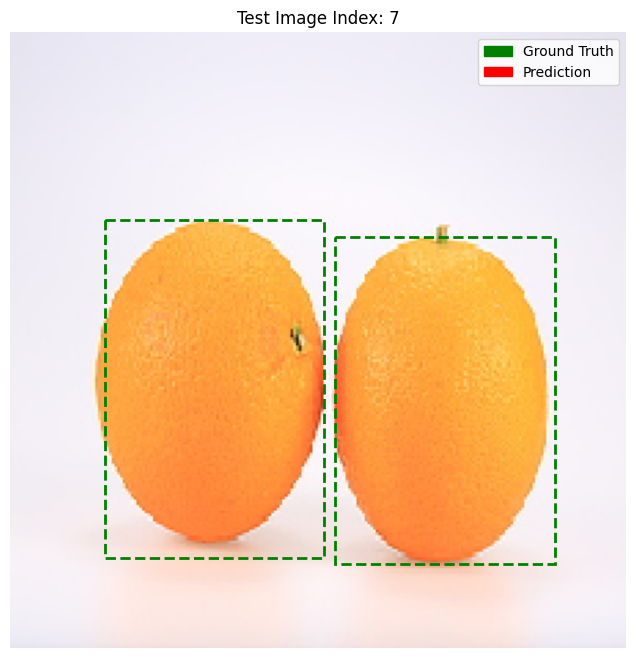

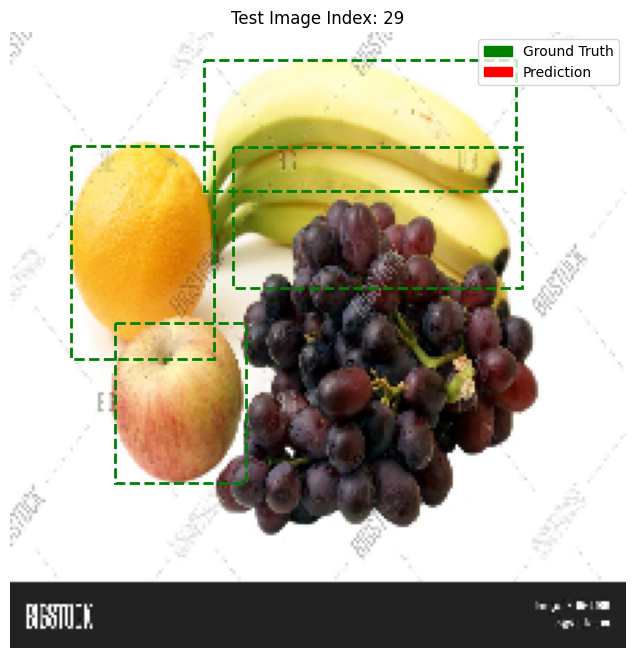

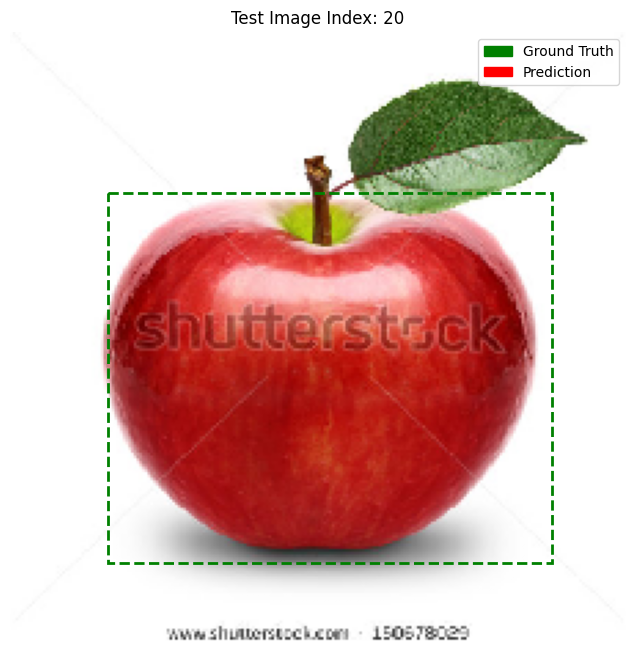

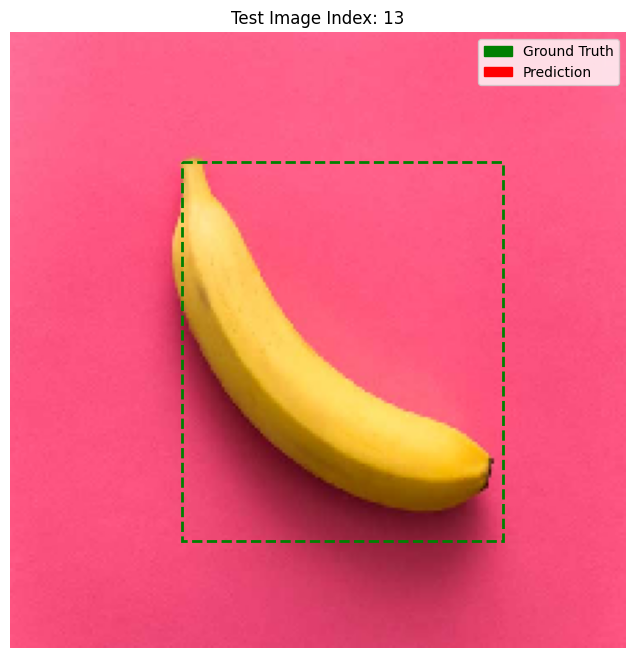

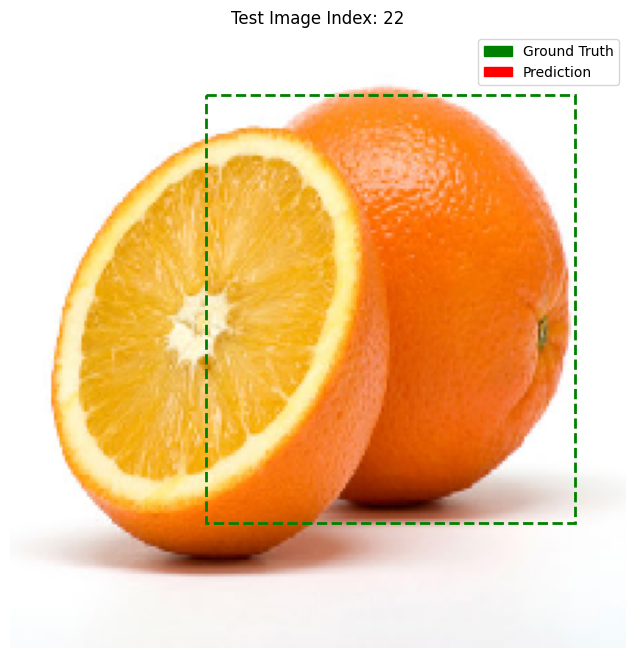

In [111]:
predict_and_visualize(loaded_model, X_test, y_test, num_samples=5)